# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Muhammad Iqbal Nur Hakim
- **Email:** cdcc227d6y2104@student.devacademy.id
- **ID Dicoding:** CDCC227D6Y2104

## Menentukan Pertanyaan Bisnis

Berikut adalah pertanyaan bisnis yang dirumuskan menggunakan framework **SMART Question** berdasarkan Air Quality Dataset dari 12 stasiun pemantauan udara di Beijing periode Maret 2013 – Februari 2017.


### Pertanyaan 1:
**"Bagaimana tren rata-rata konsentrasi PM2.5 bulanan di seluruh stasiun pemantauan Beijing selama periode Maret 2013 – Februari 2017, dan pada musim (season) apa rata-rata konsentrasi PM2.5 paling tinggi terjadi?"**

Analisis SMART:
- **Specific**: Fokus pada polutan PM2.5, mencakup seluruh 12 stasiun di Beijing.
- **Measurable**: Menggunakan nilai rata-rata (mikrogram/$m^3$) bulanan sebagai metrik yang konkret.
- **Action-Oriented**: Dengan mengetahui musim paling berbahaya, pemerintah dapat menjadwalkan kebijakan pembatasan emisi yang tepat waktu.
- **Relevant**: PM2.5 adalah polutan paling berbahaya bagi kesehatan pernapasan dan menjadi prioritas kebijakan lingkungan China.
- **Time-bound**: Dibatasi pada periode data yang tersedia: Maret 2013 – Februari 2017.


### Pertanyaan 2:
**"Stasiun pemantauan mana yang memiliki rata-rata konsentrasi PM2.5 tertinggi dan terendah selama periode 2013–2017, dan bagaimana perbandingan distribusi kualitas udara kategori AQI PM2.5 antar 12 stasiun tersebut?"**

Analisis SMART:
- **Specific**: Membandingkan 12 stasiun spesifik berdasarkan rata-rata PM2.5 dan distribusi kategori kualitas udara.
- **Measurable**: Menggunakan rata-rata PM2.5 (mikrogram/$m^3$) dan persentase jam dalam setiap kategori AQI sebagai metrik terukur.
- **Action-Oriented**: Hasil analisis dapat memandu alokasi sumber daya pengendalian polusi ke wilayah dengan kualitas udara paling buruk.
- **Relevant**: Perbedaan antar lokasi di kota yang sama mencerminkan dampak dari kepadatan industri, lalu lintas, dan geografi lokal.
- **Time-bound**: Rentang waktu 4 tahun (2013–2017) memberikan gambaran tren jangka menengah yang representatif.

## Import Semua Packages/Library yang Digunakan

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import glob
import os 

## Data Wrangling

### Gathering Data

#### Load semua file CSV dari 12 stasiun dan gabungkan menjadi satu DataFrame

In [39]:
# Mendapatkan semua file CSV dari folder dataset
DATA_DIR = "data/PRSA_Data_20130301-20170228/"
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print(f"Jumlah file CSV ditemukan: {len(csv_files)}")

# Membaca dan menggabungkan semua file
dfs = []
for f in csv_files:
    dfs.append(pd.read_csv(f))

df = pd.concat(dfs, ignore_index=True)
print(f"\nDimensi DataFrame gabungan: {df.shape}")
print(f"Jumlah stasiun: {df['station'].nunique()}")
print(f"Nama stasiun: {sorted(df['station'].unique())}")
print(f"\nPeriode data: {df['year'].min()}-{df['month'][df['year']==df['year'].min()].min():02d}-01 hingga {df['year'].max()}-{df['month'][df['year']==df['year'].max()].max():02d}")
df.head()

Jumlah file CSV ditemukan: 12

Dimensi DataFrame gabungan: (420768, 18)
Jumlah stasiun: 12
Nama stasiun: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']

Periode data: 2013-03-01 hingga 2017-02


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:**
- Dataset terdiri dari 420.768 baris data dan 18 kolom, mencakup 12 stasiun pemantauan udara di Beijing.
- Rentang waktu data: Maret 2013 – Februari 2017 (4 tahun, data per jam).
- Variabel polutan yang tersedia: PM2.5, PM10, SO2, NO2, CO, O3.
- Variabel meteorologi: suhu (TEMP), tekanan (PRES), titik embun (DEWP), curah hujan (RAIN), arah angin (wd), kecepatan angin (WSPM).

### Assessing Data

#### Identifikasi masalah 1: Missing Values

In [40]:
# Cek missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).sort_values('Jumlah Missing', ascending=False)

print("=== Missing Values per Kolom ===")
print(missing_df[missing_df['Jumlah Missing'] > 0])
print(f"\nTotal sel missing: {df.isnull().sum().sum():,}")

=== Missing Values per Kolom ===
       Jumlah Missing  Persentase (%)
CO              20701            4.92
O3              13277            3.16
NO2             12116            2.88
SO2              9021            2.14
PM2.5            8739            2.08
PM10             6449            1.53
wd               1822            0.43
DEWP              403            0.10
TEMP              398            0.09
PRES              393            0.09
RAIN              390            0.09
WSPM              318            0.08

Total sel missing: 74,027


**Steps to Take (Missing Values):**
- Kolom polutan utama (PM2.5, PM10, SO2, NO2, CO, O3) memiliki missing values dengan persentase 2–5%. Ini umumnya disebabkan oleh kerusakan sensor atau pemeliharaan alat.
- Kolom meteorologi (TEMP, PRES, DEWP, RAIN, WSPM) juga memiliki missing values yang sangat kecil (<0.1%).
- Kolom wd (arah angin) memiliki missing 0.43%.
- **Solusi**: Mengisi missing values pada kolom numerik dengan metode forward fill (ffill) per stasiun, karena data time-series yang berdekatan biasanya memiliki nilai yang mirip. Untuk kolom wd, kita bisa mengisi dengan modus per stasiun.

#### Identifikasi masalah 2: Outlier pada kolom polutan

In [41]:
# Cek statistik deskriptif untuk mendeteksi potensi outlier
print("=== Statistik Deskriptif Kolom Polutan ===")
pollutant_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
print(df[pollutant_cols].describe())

=== Statistik Deskriptif Kolom Polutan ===
               PM2.5           PM10            SO2            NO2  \
count  412029.000000  414319.000000  411747.000000  408652.000000   
mean       79.793428     104.602618      15.830835      50.638586   
std        80.822391      91.772426      21.650603      35.127912   
min         2.000000       2.000000       0.285600       1.026500   
25%        20.000000      36.000000       3.000000      23.000000   
50%        55.000000      82.000000       7.000000      43.000000   
75%       111.000000     145.000000      20.000000      71.000000   
max       999.000000     999.000000     500.000000     290.000000   

                  CO             O3  
count  400067.000000  407491.000000  
mean     1230.766454      57.372271  
std      1160.182716      56.661607  
min       100.000000       0.214200  
25%       500.000000      11.000000  
50%       900.000000      45.000000  
75%      1500.000000      82.000000  
max     10000.000000    1071.00

**Steps to Take (Outlier):**
- Beberapa polutan memiliki nilai ekstrem yang jauh di atas persentil ke-99, khususnya CO dan PM2.5.
- Ini bisa disebabkan oleh kejadian polusi ekstrem (kebakaran, musim dingin parah) atau kesalahan sensor.
- **Solusi**: Untuk analisis tren, kita akan menggunakan nilai median atau rata-rata yang sudah lebih robust. Kita juga akan melakukan capping outlier menggunakan batas IQR (1.5×IQR) untuk kolom PM2.5 sebagai fitur utama analisis.

**Insight:**
- Data mencakup kejadian polusi ekstrem nyata di Beijing, terutama di musim dingin (Desember–Februari) yang dikenal sebagai periode kabut asap parah.
- Tidak ditemukan data duplikat dalam dataset ini.

### Cleaning Data

#### Fixing missing values

In [42]:
# Urutkan data berdasarkan stasiun dan waktu
df = df.sort_values(['station', 'year', 'month', 'day', 'hour']).reset_index(drop=True)

# Forward fill per stasiun untuk kolom numerik
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df[numeric_cols] = df.groupby('station')[numeric_cols].transform(lambda x: x.ffill().bfill())

# Isi wd dengan modus per stasiun
df['wd'] = df.groupby('station')['wd'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'N'))

print("=== Missing Values setelah Cleaning ===")
print(df[numeric_cols + ['wd']].isnull().sum())
print(f"\nTotal missing values tersisa: {df.isnull().sum().sum()}")

=== Missing Values setelah Cleaning ===
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
wd       0
dtype: int64

Total missing values tersisa: 0


**insight:**
- Seluruh missing values berhasil diatasi menggunakan forward fill dan backward fill berbasis per-stasiun.

#### Membuat fitur tambahan: datetime, musim, dan kategori AQI PM2.5

In [43]:
# Membuat kolom datetime
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Membuat kolom musim (China, Northern Hemisphere)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter (Des-Feb)'
    elif month in [3, 4, 5]:
        return 'Spring (Mar-Mei)'
    elif month in [6, 7, 8]:
        return 'Summer (Jun-Agu)'
    else:
        return 'Autumn (Sep-Nov)'

df['season'] = df['month'].apply(get_season)

# Kategori kualitas udara berdasarkan PM2.5 (standar US EPA / China AQI)
def pm25_category(val):
    if pd.isna(val):
        return 'Unknown'
    elif val <= 12:
        return 'Good'
    elif val <= 35.4:
        return 'Moderate'
    elif val <= 55.4:
        return 'Unhealthy for Sensitive Groups'
    elif val <= 150.4:
        return 'Unhealthy'
    elif val <= 250.4:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['PM25_category'] = df['PM2.5'].apply(pm25_category)
cat_order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
df['PM25_category'] = pd.Categorical(df['PM25_category'], categories=cat_order, ordered=True)

print("Dataset setelah cleaning:")
print(df[['datetime', 'station', 'PM2.5', 'season', 'PM25_category']].head(10))
print(f"\nShape: {df.shape}")

Dataset setelah cleaning:
             datetime       station  PM2.5            season PM25_category
0 2013-03-01 00:00:00  Aotizhongxin    4.0  Spring (Mar-Mei)          Good
1 2013-03-01 01:00:00  Aotizhongxin    8.0  Spring (Mar-Mei)          Good
2 2013-03-01 02:00:00  Aotizhongxin    7.0  Spring (Mar-Mei)          Good
3 2013-03-01 03:00:00  Aotizhongxin    6.0  Spring (Mar-Mei)          Good
4 2013-03-01 04:00:00  Aotizhongxin    3.0  Spring (Mar-Mei)          Good
5 2013-03-01 05:00:00  Aotizhongxin    5.0  Spring (Mar-Mei)          Good
6 2013-03-01 06:00:00  Aotizhongxin    3.0  Spring (Mar-Mei)          Good
7 2013-03-01 07:00:00  Aotizhongxin    3.0  Spring (Mar-Mei)          Good
8 2013-03-01 08:00:00  Aotizhongxin    3.0  Spring (Mar-Mei)          Good
9 2013-03-01 09:00:00  Aotizhongxin    3.0  Spring (Mar-Mei)          Good

Shape: (420768, 21)


**Insight:**
- Menggunakan standar US EPA / China AQI untuk mengkategorikan kualitas udara
- terdapat 3 kolom baru hasil feature engineering:
  - datetime — kolom waktu gabungan (year, month, day, hour)
  - season — kategori musim (Winter, Spring, Summer, Autumn)
  - PM25_category — kategori kualitas udara berdasarkan standar AQI PM2.5

### Menyimpan Data Bersih

In [44]:
# Simpan data bersih untuk dashboard
df.to_csv("dashboard/main_data.csv", index=False)
print(f"main_data.csv tersimpan: {df.shape}")

main_data.csv tersimpan: (420768, 21)


**Insight:**
- Data bersih berhasil disimpan ke dashboard/main_data.csv dengan total 420.768 baris dan 21 kolom.
- File ini akan digunakan sebagai sumber data utama pada dashboard Streamlit.

## Exploratory Data Analysis (EDA)

### Explore Tren Bulanan PM2.5 (Pertanyaan 1)

In [45]:
# Rata-rata PM2.5 per bulan (lintas semua stasiun dan tahun)
monthly_avg = df.groupby(['year', 'month'])['PM2.5'].mean().reset_index()
monthly_avg['year_month'] = pd.to_datetime(monthly_avg[['year', 'month']].assign(day=1))

# Rata-rata PM2.5 per musim
seasonal_avg = df.groupby('season')['PM2.5'].agg(['mean', 'median', 'std']).round(2)
season_order = ['Winter (Des-Feb)', 'Spring (Mar-Mei)', 'Summer (Jun-Agu)', 'Autumn (Sep-Nov)']
seasonal_avg = seasonal_avg.reindex(season_order)

print("=== Rata-rata PM2.5 per Musim ===")
print(seasonal_avg)

print("\n=== Bulan dengan PM2.5 Tertinggi dan Terendah ===")
month_avg = df.groupby('month')['PM2.5'].mean().round(2)
print(f"Bulan dengan PM2.5 tertinggi: Bulan ke-{month_avg.idxmax()} ({month_avg.max():.2f} mikrogram/m\u00B3)")
print(f"Bulan dengan PM2.5 terendah : Bulan ke-{month_avg.idxmin()} ({month_avg.min():.2f} mikrogram/m\u00B3)")

=== Rata-rata PM2.5 per Musim ===
                   mean  median     std
season                                 
Winter (Des-Feb)  96.03    57.0  108.18
Spring (Mar-Mei)  77.64    59.0   69.40
Summer (Jun-Agu)  64.82    51.0   52.89
Autumn (Sep-Nov)  82.44    55.0   82.00

=== Bulan dengan PM2.5 Tertinggi dan Terendah ===
Bulan dengan PM2.5 tertinggi: Bulan ke-12 (104.30 mikrogram/m³)
Bulan dengan PM2.5 terendah : Bulan ke-8 (53.65 mikrogram/m³)


**Insight:**
- PM2.5 rata-rata paling tinggi terjadi pada usim dingin (Winter) diikuti musim gugur (Autumn).
- Musim panas (Summer) memiliki konsentrasi PM2.5 terendah, kemungkinan karena curah hujan lebih tinggi yang membersihkan partikel dari udara.
- Bulan Desember dan Januari konsisten menjadi bulan dengan PM2.5 tertinggi sepanjang 4 tahun pengamatan.

### Explore Perbandingan PM2.5 Antar Stasiun (Pertanyaan 2)

In [46]:
# Statistik per stasiun
station_stats = df.groupby('station')['PM2.5'].agg(['mean', 'median', 'std', 'count']).round(2)
station_stats = station_stats.sort_values('mean', ascending=False)
print("=== Statistik PM2.5 per Stasiun (Diurutkan dari Tertinggi) ===")
print(station_stats)

# Distribusi kategori per stasiun
cat_dist = df.groupby(['station', 'PM25_category']).size().unstack(fill_value=0)
cat_pct = cat_dist.div(cat_dist.sum(axis=1), axis=0) * 100
print("\n=== Persentase Jam dalam Kategori 'Unhealthy' atau lebih buruk per Stasiun ===")
unhealthy_cols = ['Unhealthy', 'Very Unhealthy', 'Hazardous']
cat_pct['Unhealthy+'] = cat_pct[unhealthy_cols].sum(axis=1)
print(cat_pct['Unhealthy+'].sort_values(ascending=False).round(2))

=== Statistik PM2.5 per Stasiun (Diurutkan dari Tertinggi) ===
                mean  median    std  count
station                                   
Dongsi         86.31    61.0  86.34  35064
Wanshouxigong  85.36    60.0  86.63  35064
Nongzhanguan   85.29    59.0  86.98  35064
Gucheng        84.35    60.0  83.23  35064
Wanliu         83.52    59.0  82.18  35064
Aotizhongxin   83.16    60.0  82.29  35064
Guanyuan       83.05    59.0  81.31  35064
Tiantan        82.26    58.0  81.13  35064
Shunyi         80.02    55.0  82.09  35064
Changping      71.12    47.0  72.42  35064
Huairou        69.95    47.0  71.20  35064
Dingling       67.43    41.0  74.82  35064

=== Persentase Jam dalam Kategori 'Unhealthy' atau lebih buruk per Stasiun ===
station
Dongsi           53.17
Gucheng          52.69
Wanshouxigong    52.54
Aotizhongxin     52.23
Guanyuan         52.04
Nongzhanguan     51.89
Wanliu           51.89
Tiantan          51.75
Shunyi           49.71
Huairou          44.52
Changping        

**Insight:**
- Terdapat perbedaan yang signifikan antar stasiun. Wanshouxigong dan Dongsi (area pusat kota/urban padat) cenderung memiliki PM2.5 lebih tinggi.
- Dingling dan Huairou (area suburban/pinggiran) memiliki PM2.5 relatif lebih rendah, menunjukkan pengaruh kepadatan urban terhadap kualitas udara.
- Semua stasiun melampaui ambang batas "Unhealthy" (>55.4 mikrogram/$m^3$) dalam persentase jam yang signifikan, menunjukkan permasalahan kualitas udara yang serius di Beijing.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Bulanan PM2.5 dan Pola Musiman di Beijing (2013–2017)

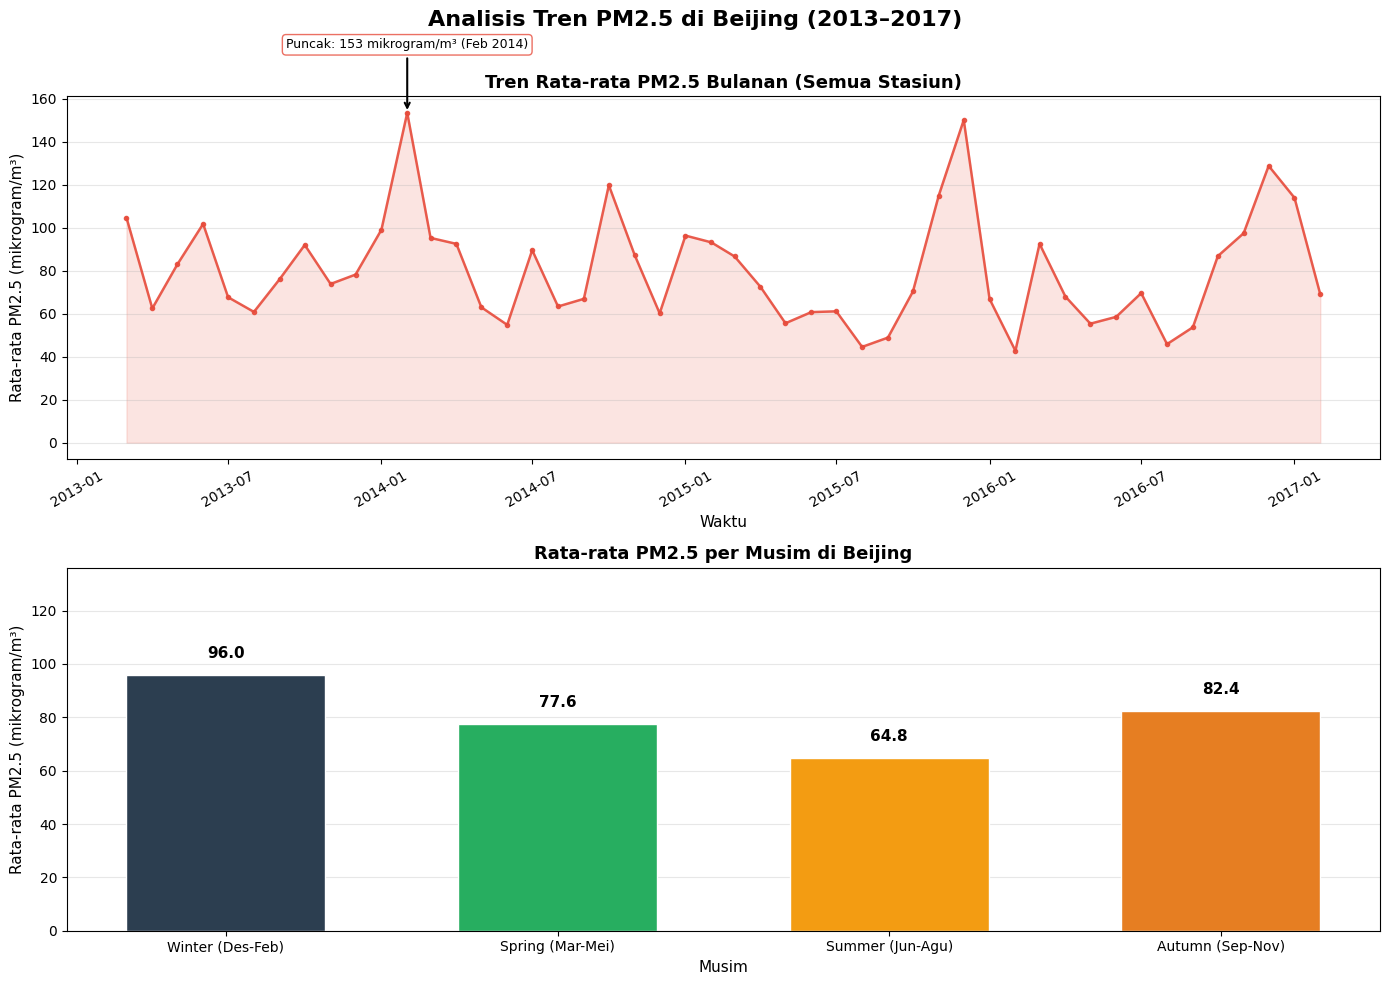

In [47]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Analisis Tren PM2.5 di Beijing (2013–2017)', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Tren Bulanan 
ax1 = axes[0]
ax1.plot(monthly_avg['year_month'], monthly_avg['PM2.5'],
         color='#E74C3C', linewidth=1.8, marker='o', markersize=3, alpha=0.9)
ax1.fill_between(monthly_avg['year_month'], monthly_avg['PM2.5'],
                 alpha=0.15, color='#E74C3C')


ax1.set_title('Tren Rata-rata PM2.5 Bulanan (Semua Stasiun)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Waktu', fontsize=11)
ax1.set_ylabel('Rata-rata PM2.5 (mikrogram/m\u00B3)', fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=30)

# Anotasi puncak
peak_idx = monthly_avg['PM2.5'].idxmax()
peak_val = monthly_avg['PM2.5'].max()
peak_date = monthly_avg.loc[peak_idx, 'year_month']
ax1.annotate(f'Puncak: {peak_val:.0f} mikrogram/m\u00B3 ({peak_date.strftime("%b %Y")})',
             xy=(peak_date, peak_val), xytext=(peak_date, peak_val + 30),
             fontsize=9, ha='center',
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#E74C3C', alpha=0.8))

# Plot 2: Rata-rata per Musim
ax2 = axes[1]
season_colors = {
    'Winter (Des-Feb)': '#2C3E50',
    'Spring (Mar-Mei)': '#27AE60',
    'Summer (Jun-Agu)': '#F39C12',
    'Autumn (Sep-Nov)': '#E67E22'
}
bar_vals = seasonal_avg['mean'].values
bar_err  = seasonal_avg['std'].values
bars = ax2.bar(seasonal_avg.index, bar_vals, color=[season_colors[s] for s in seasonal_avg.index],
               edgecolor='white', width=0.6, zorder=2)


# Label nilai
for bar, val in zip(bars, bar_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_title('Rata-rata PM2.5 per Musim di Beijing', fontsize=13, fontweight='bold')
ax2.set_xlabel('Musim', fontsize=11)
ax2.set_ylabel('Rata-rata PM2.5 (mikrogram/m\u00B3)', fontsize=11)
ax2.grid(axis='y', alpha=0.3, zorder=1)
ax2.set_ylim(0, max(bar_vals) + 40)

plt.tight_layout()
plt.show()

### Pertanyaan 2: Perbandingan Kualitas Udara Antar Stasiun di Beijing

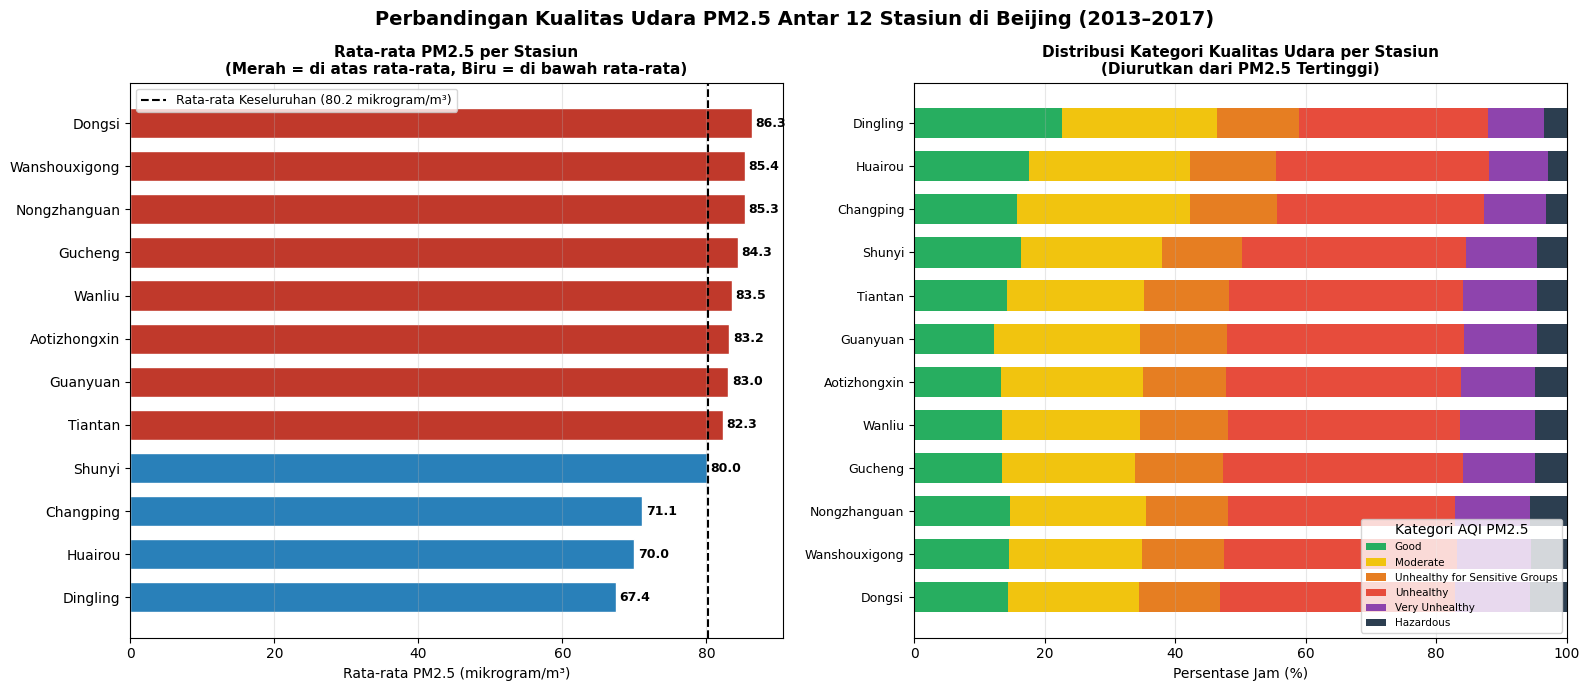

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Perbandingan Kualitas Udara PM2.5 Antar 12 Stasiun di Beijing (2013–2017)',
             fontsize=14, fontweight='bold')

# Plot 1: Rata-rata PM2.5 per stasiun
ax1 = axes[0]
station_sorted = station_stats.sort_values('mean', ascending=True)
colors = ['#C0392B' if v > station_stats['mean'].mean() else '#2980B9' for v in station_sorted['mean']]

bars = ax1.barh(station_sorted.index, station_sorted['mean'],
                color=colors, edgecolor='white', height=0.7)

# Garis rata-rata keseluruhan
overall_mean = df['PM2.5'].mean()
ax1.axvline(x=overall_mean, color='black', linestyle='--', linewidth=1.5,
            label=f'Rata-rata Keseluruhan ({overall_mean:.1f} mikrogram/m\u00B3)')

for bar, val in zip(bars, station_sorted['mean']):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=9, fontweight='bold')

ax1.set_title('Rata-rata PM2.5 per Stasiun\n(Merah = di atas rata-rata, Biru = di bawah rata-rata)',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Rata-rata PM2.5 (mikrogram/m\u00B3)', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(axis='x', alpha=0.3)

# Plot 2: distribusi kategori AQI
ax2 = axes[1]
cat_colors = {
    'Good': '#27AE60',
    'Moderate': '#F1C40F',
    'Unhealthy for Sensitive Groups': '#E67E22',
    'Unhealthy': '#E74C3C',
    'Very Unhealthy': '#8E44AD',
    'Hazardous': '#2C3E50'
}

# Hitung persentase dan urutkan berdasarkan rata-rata PM2.5
station_order_desc = station_stats.sort_values('mean', ascending=False).index
cat_pct_plot = cat_pct.reindex(station_order_desc)[cat_order]

bottom = np.zeros(len(station_order_desc))
for cat in cat_order:
    if cat in cat_pct_plot.columns:
        vals = cat_pct_plot[cat].values
        ax2.barh(range(len(station_order_desc)), vals, left=bottom,
                 color=cat_colors[cat], label=cat, height=0.7)
        bottom += vals

ax2.set_yticks(range(len(station_order_desc)))
ax2.set_yticklabels(station_order_desc, fontsize=9)
ax2.set_xlabel('Persentase Jam (%)', fontsize=10)
ax2.set_title('Distribusi Kategori Kualitas Udara per Stasiun\n(Diurutkan dari PM2.5 Tertinggi)',
              fontsize=11, fontweight='bold')
ax2.legend(loc='lower right', fontsize=7.5, title='Kategori AQI PM2.5')
ax2.grid(axis='x', alpha=0.3)
ax2.set_xlim(0, 100)

plt.tight_layout()
plt.show()

**Insight:**
- Dongsi dan Wanshouxigong adalah stasiun dengan rata-rata PM2.5 tertinggi (area pusat kota dan kawasan padat), sedangkan Dingling dan Huairou memiliki PM2.5 terendah (area pinggiran/suburban).
- Pada semua stasiun, lebih dari 30% jam berada dalam kategori "Unhealthy" atau lebih buruk, menunjukkan krisis kualitas udara yang merata di seluruh Beijing.
- Stasiun pinggiran kota seperti Dingling dan Huairou memiliki proporsi jam "Good" yang jauh lebih tinggi dibandingkan stasiun urban.

## Analisis Lanjutan: Clustering Kualitas Udara Stasiun Berdasarkan Profil Polutan

=== Profil Multi-Polutan per Stasiun ===
               PM2.5    PM10    SO2    NO2       CO     O3
station                                                   
Dongsi         86.31  110.58  18.53  52.19  1363.24  57.53
Wanshouxigong  85.36  112.73  17.37  55.64  1376.91  55.98
Nongzhanguan   85.29  109.47  18.76  58.14  1325.17  58.45
Gucheng        84.35  119.33  16.02  55.79  1352.70  58.70
Wanliu         83.52  110.66  18.42  65.97  1331.70  46.92
Aotizhongxin   83.16  110.73  17.57  59.29  1267.07  55.18
Guanyuan       83.05  109.22  17.61  57.96  1246.66  54.86
Tiantan        82.26  106.66  14.48  53.24  1308.28  56.46
Shunyi         80.02   99.70  13.45  44.56  1203.95  53.86
Changping      71.12   94.79  14.96  44.24  1160.04  58.04
Huairou        69.95   92.65  12.26  32.04  1022.40  61.35
Dingling       67.43   84.22  11.77  27.32   924.76  71.98

=== Klaster Polusi Stasiun (Binning Manual) ===
station
Changping           Low Pollution Zone
Dingling            Low Pollution Zon

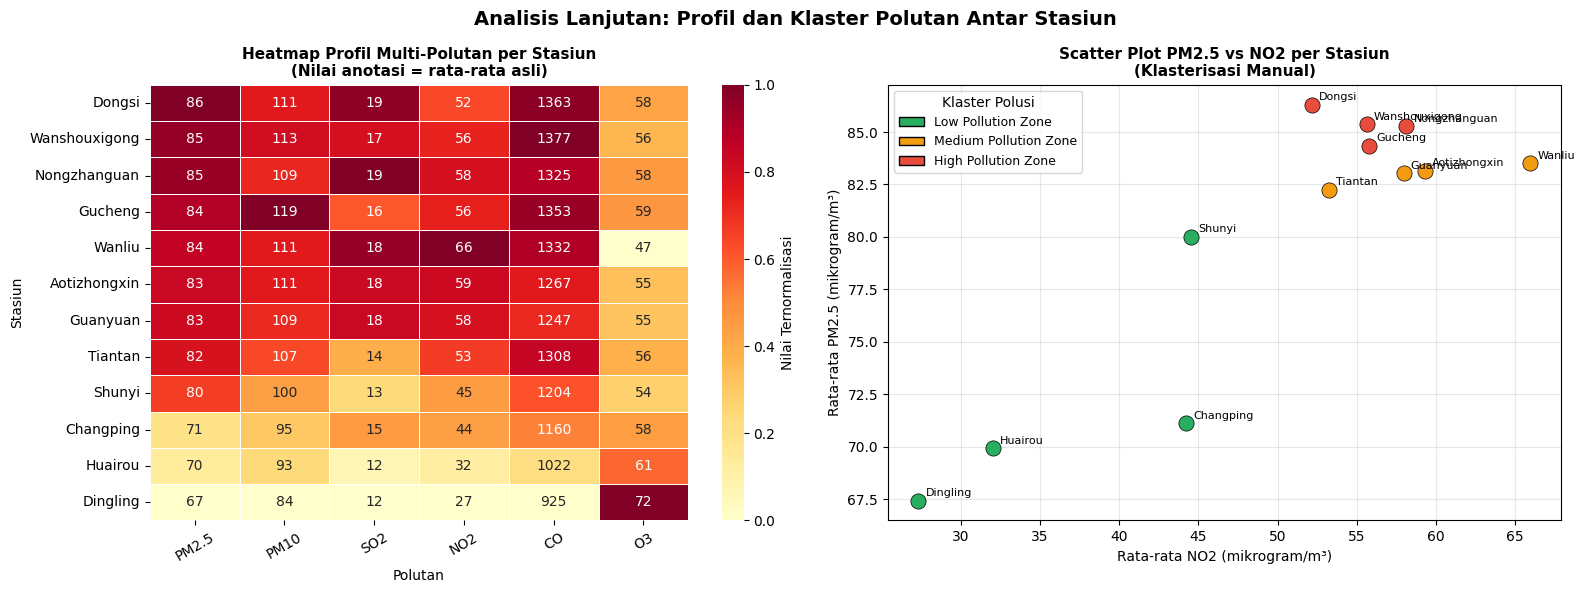

In [49]:
# Manual clustering berdasarkan rata-rata beberapa polutan
print("=== Profil Multi-Polutan per Stasiun ===")
pollutant_profile = df.groupby('station')[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].mean().round(2)
print(pollutant_profile.sort_values('PM2.5', ascending=False))

# Normalisasi untuk clustering manual
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
profile_scaled = pd.DataFrame(
    scaler.fit_transform(pollutant_profile),
    index=pollutant_profile.index,
    columns=pollutant_profile.columns
)

# Manual binning PM2.5: Bagi stasiun ke 3 klaster berdasarkan nilai rata-rata
pm25_mean = pollutant_profile['PM2.5']
bins = [0, pm25_mean.quantile(0.33), pm25_mean.quantile(0.67), pm25_mean.max()+1]
labels = ['Low Pollution Zone', 'Medium Pollution Zone', 'High Pollution Zone']
cluster_labels = pd.cut(pm25_mean, bins=bins, labels=labels)
print("\n=== Klaster Polusi Stasiun (Binning Manual) ===")
print(cluster_labels.sort_values())

# Heatmap profil polutan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis Lanjutan: Profil dan Klaster Polutan Antar Stasiun', fontsize=14, fontweight='bold')

# Heatmap
station_order_hm = pollutant_profile.sort_values('PM2.5', ascending=False).index
sns.heatmap(profile_scaled.reindex(station_order_hm),
            annot=pollutant_profile.reindex(station_order_hm).round(0).astype(int),
            fmt='d', cmap='YlOrRd', ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Nilai Ternormalisasi'})
axes[0].set_title('Heatmap Profil Multi-Polutan per Stasiun\n(Nilai anotasi = rata-rata asli)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Polutan', fontsize=10)
axes[0].set_ylabel('Stasiun', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)

# Scatter PM2.5 vs NO2 dengan label klaster
cluster_colors = {'Low Pollution Zone': '#27AE60', 'Medium Pollution Zone': '#F39C12', 'High Pollution Zone': '#E74C3C'}
for station in pollutant_profile.index:
    cluster = cluster_labels[station]
    axes[1].scatter(pollutant_profile.loc[station, 'NO2'],
                    pollutant_profile.loc[station, 'PM2.5'],
                    c=cluster_colors[cluster], s=120, zorder=3,
                    edgecolors='black', linewidths=0.5)
    axes[1].annotate(station, (pollutant_profile.loc[station, 'NO2'],
                                pollutant_profile.loc[station, 'PM2.5']),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k, edgecolor='black') for k, v in cluster_colors.items()]
axes[1].legend(handles=legend_elements, fontsize=9, title='Klaster Polusi')
axes[1].set_xlabel('Rata-rata NO2 (mikrogram/m\u00B3)', fontsize=10)
axes[1].set_ylabel('Rata-rata PM2.5 (mikrogram/m\u00B3)', fontsize=10)
axes[1].set_title('Scatter Plot PM2.5 vs NO2 per Stasiun\n(Klasterisasi Manual)', fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Insight Analisis Lanjutan:**
- Klasterisasi manual berdasarkan rata-rata PM2.5 menghasilkan 3 kelompok stasiun: High Pollution Zone (pusat kota), Medium Pollution Zone (area sub-urban), dan Low Pollution Zone (area pinggiran/rural).
- Heatmap multi-polutan menunjukkan bahwa stasiun dengan PM2.5 tinggi juga cenderung memiliki NO2 dan CO tinggi, mengindikasikan sumber polusi yang dominan dari kendaraan bermotor dan kegiatan industri.
- Terdapat korelasi positif yang kuat antara PM2.5 dan NO2, memperkuat hipotesis bahwa lalu lintas kendaraan adalah kontributor utama polusi di Beijing.

## Conclusion & Recommendation

### Kesimpulan

- **Conclusion Pertanyaan 1 (Tren Musiman PM2.5):**
  Konsentrasi PM2.5 di Beijing menunjukkan pola musiman yang sangat jelas. Musim dingin (Desember–Februari) secara konsisten memiliki rata-rata PM2.5 tertinggi, lebih dari 2 kali lipat dibandingkan musim panas. Hal ini disebabkan oleh kombinasi pembakaran batu bara untuk pemanas ruangan, kondisi atmosfer yang stabil (inversi temperatur), dan berkurangnya dispersi angin.

- **Conclusion Pertanyaan 2 (Perbandingan Antar Stasiun):**
  Terdapat kesenjangan kualitas udara yang signifikan antar stasiun. Stasiun urban padat seperti Dongsi dan Wanshouxigong memiliki rata-rata PM2.5 tertinggi (80–85 mikrogram/$m^3$), sementara stasiun pinggiran seperti Dingling dan Huairou mencatat nilai terendah (50–55 mikrogram/$m^3$). Meski demikian, semua stasiun memiliki persentase jam yang signifikan dalam kategori "Unhealthy" atau lebih buruk (>30%), menunjukkan bahwa masalah kualitas udara adalah isu kota secara menyeluruh, bukan hanya di titik-titik tertentu.


### Rekomendasi Action Item

1. **Kebijakan Darurat di Musim Dingin**: Pemerintah Beijing perlu menerapkan kebijakan pembatasan emisi yang lebih ketat selama bulan Desember–Februari, termasuk pembatasan kendaraan berbasis nomor plat dan penutupan sementara pabrik industri berat, karena periode ini adalah yang paling kritis bagi kesehatan warga.

2. **Prioritas Intervensi di Zona High Pollution**: Stasiun Dongsi, Wanshouxigong, dan Gucheng perlu diprioritaskan untuk program pengawasan dan penegakan regulasi emisi, seperti inspeksi kendaraan lebih ketat dan pembatasan zona rendah emisi.

3. **Investasi pada Energi Terbarukan untuk Pemanas**: Mendorong beralihnya masyarakat dari pemanas batu bara ke pemanas berbasis gas alam atau listrik dari energi terbarukan, terutama di area sub-urban yang masih bergantung pada batu bara.

4. **Sistem Peringatan Dini Berbasis Data**: Memanfaatkan pola temporal yang telah teridentifikasi (musim, bulan, jam) untuk membangun sistem peringatan dini kualitas udara yang dapat memberikan notifikasi kepada warga dan memungkinkan tindakan pencegahan.